<a href="https://colab.research.google.com/github/Elijah-Mumo/XAI_ELIAS_DS_R_Projects-crispy_waffle/blob/main/Financial_Inclusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#important packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
np.random.seed(123)
warnings.filterwarnings('ignore')
%matplotlib inline

In [7]:
# Import data
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')

# print shape
print('train data shape :', train.shape)
print('test data shape :', test.shape)

# inspect train data
print(train.head())


#Information about the dataset

print(train.info())

train data shape : (23524, 13)
test data shape : (10086, 12)
  country  year    uniqueid bank_account location_type cellphone_access  \
0   Kenya  2018  uniqueid_1          Yes         Rural              Yes   
1   Kenya  2018  uniqueid_2           No         Rural               No   
2   Kenya  2018  uniqueid_3          Yes         Urban              Yes   
3   Kenya  2018  uniqueid_4           No         Rural              Yes   
4   Kenya  2018  uniqueid_5           No         Urban               No   

   household_size  age_of_respondent gender_of_respondent  \
0               3                 24               Female   
1               5                 70               Female   
2               5                 26                 Male   
3               5                 34               Female   
4               8                 26                 Male   

  relationship_with_head           marital_status  \
0                 Spouse  Married/Living together   
1      Head of 

In [16]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Convert target label to numerical Data
le = LabelEncoder()
train['bank_account'] = le.fit_transform(train['bank_account'])

# Separate training features from target
X_train = train.drop(['bank_account'], axis=1)
y_train = train['bank_account']

print(y_train)

# Define numerical and categorical features for preprocessing
numerical_features = ["household_size", "age_of_respondent", "year"]
categorical_features = [
    "country",
    "location_type",
    "cellphone_access",
    "gender_of_respondent",
    "relationship_with_head",
    "marital_status",
    "education_level",
    "job_type"
]

# Create a column transformer for preprocessing
# Scale numerical features and One-Hot Encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features) # Set sparse_output to False
    ],
    remainder='drop'
)


0        1
1        0
2        1
3        0
4        0
        ..
23519    0
23520    0
23521    0
23522    0
23523    0
Name: bank_account, Length: 23524, dtype: int64


In [15]:
# Drop 'uniqueid' column before preprocessing and store test uniqueids
X_train_processed_df = X_train.drop(['uniqueid'], axis=1)
test_ids = test['uniqueid'] # Store unique IDs for submission
test_processed_df = test.drop(['uniqueid'], axis=1)

# Fit the preprocessor on the training data and transform both train and test data
processed_train_array = preprocessor.fit_transform(X_train_processed_df).toarray()
processed_test_array = preprocessor.transform(test_processed_df).toarray()

# Get feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

# Convert processed arrays back to DataFrames to retain column names
processed_train = pd.DataFrame(processed_train_array, columns=all_feature_names)
processed_test = pd.DataFrame(processed_test_array, columns=all_feature_names)

# Display the first processed train row and its shape
print('Processed Train Data Sample (first row):')
print(processed_train.head(1))
print('Shape of Processed Train Data:', processed_train.shape)

# Split train_data into training and validation sets
from sklearn.model_selection import train_test_split

X_Train, X_Val, y_Train, y_val = train_test_split(processed_train, y_train, stratify=y_train,
                                                  test_size=0.1, random_state=42)


Processed Train Data Sample (first row):
   household_size  age_of_respondent  year  country_Kenya  country_Rwanda  \
0             0.1           0.095238   1.0            1.0             0.0   

   country_Tanzania  country_Uganda  location_type_Rural  location_type_Urban  \
0               0.0             0.0                  1.0                  0.0   

   cellphone_access_No  ...  job_type_Dont Know/Refuse to answer  \
0                  0.0  ...                                  0.0   

   job_type_Farming and Fishing  job_type_Formally employed Government  \
0                           0.0                                    0.0   

   job_type_Formally employed Private  job_type_Government Dependent  \
0                                 0.0                            0.0   

   job_type_Informally employed  job_type_No Income  job_type_Other Income  \
0                           0.0                 0.0                    0.0   

   job_type_Remittance Dependent  job_type_Self emplo

In [9]:
#import classifier algorithm here
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier


# create models
lg_model = LogisticRegression()
rf_model = RandomForestClassifier()
kn_model = KNeighborsClassifier()
et_model = ExtraTreesClassifier()
xg_model = XGBClassifier()

#fitting the models
lg_model.fit(X_Train,y_Train)
rf_model.fit(X_Train,y_Train)
kn_model.fit(X_Train,y_Train)
et_model.fit(X_Train,y_Train)
xg_model.fit(X_Train,y_Train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [10]:
# import evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score

# evaluate the model
lg_y_pred = lg_model.predict(X_Val)
rf_y_pred = rf_model.predict(X_Val)
kn_y_model = kn_model.predict(X_Val)
et_y_model = et_model.predict(X_Val)
xg_y_model = xg_model.predict(X_Val)

# Get error rate
print("Error rate Logistic Regression classifier: ", 1 - accuracy_score(y_val, lg_y_pred))
print("Error rate of Random Forest classifier: ", 1 - accuracy_score(y_val, rf_y_pred))
print("Error rate of K Neighbors classifier: ", 1 - accuracy_score(y_val, kn_y_model))
print("Error rate of Extra Tree classifier: ", 1 - accuracy_score(y_val, et_y_model))
print("Error rate of XGB classifier: ", 1 - accuracy_score(y_val, xg_y_model))

Error rate Logistic Regression classifier:  0.11219719507012327
Error rate of Random Forest classifier:  0.1368465788355291
Error rate of K Neighbors classifier:  0.11984700382490443
Error rate of Extra Tree classifier:  0.14747131321716955
Error rate of XGB classifier:  0.11219719507012327


In [11]:
# import evaluation metrics
from sklearn.metrics import confusion_matrix, accuracy_score

# evaluate the model
lg_y_pred = lg_model.predict(X_Val)
rf_y_pred = rf_model.predict(X_Val)
kn_y_model = kn_model.predict(X_Val)
et_y_model = et_model.predict(X_Val)
xg_y_model = xg_model.predict(X_Val)

# Get error rate
print("Error rate Logistic Regression classifier: ", 1 - accuracy_score(y_val, lg_y_pred))
print("Error rate of Random Forest classifier: ", 1 - accuracy_score(y_val, rf_y_pred))
print("Error rate of K Neighbors classifier: ", 1 - accuracy_score(y_val, kn_y_model))
print("Error rate of Extra Tree classifier: ", 1 - accuracy_score(y_val, et_y_model))
print("Error rate of XGB classifier: ", 1 - accuracy_score(y_val, xg_y_model))



Error rate Logistic Regression classifier:  0.11219719507012327
Error rate of Random Forest classifier:  0.1368465788355291
Error rate of K Neighbors classifier:  0.11984700382490443
Error rate of Extra Tree classifier:  0.14747131321716955
Error rate of XGB classifier:  0.11219719507012327


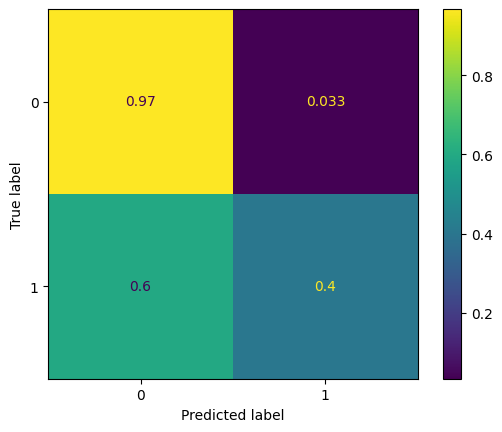

Fitting 5 folds for each of 36 candidates, totalling 180 fits
{'gamma': 0.5, 'max_depth': 3, 'min_child_weighth': 1, 'subsample': 1.0}
Error rate of the XGB classifier:  0.11517212069698257


In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

# Get confusion matrix for Gradient Boosting Classifier
ConfusionMatrixDisplay.from_estimator(xg_model,X_Val,y_val,normalize='true')
plt.show()

# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Optimize model parameters
# I run this code in google colab to make the execution much faster and use the best params in the next code
param_grid = {'min_child_weighth': [1, 5, 10],
        'gamma': [0.5, 1],
        'subsample': [0.6, 0.8, 1.0],
        'max_depth': [3, 5]
        }
my_xgb_model = GridSearchCV(xg_model, param_grid,n_jobs=-1,verbose=2,cv=5)
my_xgb_model.fit(X_Train, y_Train)
print(my_xgb_model.best_params_)

from sklearn.metrics import confusion_matrix, accuracy_score

# fit by setting best parameters and Evaluate model
xgb_model = XGBClassifier(min_child_weight=1, gamma=1, subsample=0.8, max_depth=5)

xgb_model.fit(X_Train, y_Train)
y_pred = xgb_model.predict(X_Val)

# Get error rate
print("Error rate of the XGB classifier: ", 1 - accuracy_score(y_val, y_pred))

# Get the predicted result for the test Data
test.bank_account = xgb_model.predict(processed_test)

# Create submission DataFrame
submission = pd.DataFrame({"uniqueid": test["uniqueid"] + " x " + test["country"],
                           "bank_account": test.bank_account})

#show the five sample
submission.sample(5)

# Create submission csv file csv file
submission.to_csv('ElijahM_uno_submission.csv', index = False)
